In [111]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [112]:
df_klaim = pd.read_csv('dataset/Data_Klaim.csv')
df_polis = pd.read_csv('dataset/Data_Polis.csv')
df_klaim.head(2)

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6143947.68,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,82309522.45,Malaysia


In [113]:
df_polis.head(3)

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA


1. DATA CLEANING

In [114]:
#checking missing value df_klaim
(df_klaim.isnull().sum() / len(df_klaim)) * 100

Claim ID                         0.000000
Nomor Polis                      0.000000
Reimburse/Cashless               0.000000
Inpatient/Outpatient             0.799654
ICD Diagnosis                    0.129674
ICD Description                  0.129674
Status Klaim                     0.000000
Tanggal Pembayaran Klaim         0.799654
Tanggal Pasien Masuk RS          0.000000
Tanggal Pasien Keluar RS         0.000000
Nominal Klaim Yang Disetujui     0.000000
Nominal Biaya RS Yang Terjadi    0.000000
Lokasi RS                        0.151286
dtype: float64

In [115]:
df_klaim.isna().sum()

Claim ID                          0
Nomor Polis                       0
Reimburse/Cashless                0
Inpatient/Outpatient             37
ICD Diagnosis                     6
ICD Description                   6
Status Klaim                      0
Tanggal Pembayaran Klaim         37
Tanggal Pasien Masuk RS           0
Tanggal Pasien Keluar RS          0
Nominal Klaim Yang Disetujui      0
Nominal Biaya RS Yang Terjadi     0
Lokasi RS                         7
dtype: int64

In [116]:
df_klaim[df_klaim["Tanggal Pembayaran Klaim"].isna()].head(4)


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore
5,C-0006-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-07-18,2024-07-18,1.360160e+08,1.368552e+08,Singapore
6,C-0007-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-27,2024-06-27,1.341925e+08,1.347333e+08,Singapore
7,C-0008-M,POL-0566,R,OP,C90.0,Multiple myeloma,PAID,NaN,2024-06-19,2024-06-19,5.398718e+08,3.164563e+08,Singapore


In [117]:
#mengambil kolom yang memiliki baris null di df_klaim
kolom_null_klaim = [x for x in df_klaim.columns if df_klaim[x].isna().any()]
kolom_null_klaim    

['Inpatient/Outpatient',
 'ICD Diagnosis',
 'ICD Description',
 'Tanggal Pembayaran Klaim',
 'Lokasi RS']

In [118]:
#checking missing value df_polis
df_polis.isna().sum()

Nomor Polis              0
Plan Code                0
Gender                   0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
dtype: int64

In [119]:
#checking duplcated value
df_polis.duplicated().sum()
df_klaim.duplicated().sum()

np.int64(0)

Simulasi mengatasi missing value:
- 'Tanggal Pembayaran klaim' -> Imputasi dengan "Median Lag" -> Ambil semua data yang lengkap (punya tanggal keluar RS & tanggal bayar).
Hitung selisih hari (Lag) = Tanggal Pembayaran - Tanggal Keluar RS

- 'Inpatient/Outpatient' -> diisi berdasarkan selisih tgl keluar - tgl masuk -> kalau > 0 maka Inpatient, kalo = 0 maka outpatient

- 'ICD Diagnosis'  -> Standar WHO ICD-10 (International Classification of Diseases) isi dgn 'R69' artinya Unknown and unspecified causes of morbidity (Penyebab kesakitan yang tidak diketahui/tidak spesifik).

- 'ICD Description' -> diisi "Unknown". Ini membuat model mengerti bahwa "tidak ada diagnosa" adalah sebuah kategori risiko tersendiri.

-'lokasi RS' -> isi dengan 'OTHER'

In [120]:
df_klaim.dtypes

Claim ID                             str
Nomor Polis                          str
Reimburse/Cashless                   str
Inpatient/Outpatient                 str
ICD Diagnosis                        str
ICD Description                      str
Status Klaim                         str
Tanggal Pembayaran Klaim             str
Tanggal Pasien Masuk RS              str
Tanggal Pasien Keluar RS             str
Nominal Klaim Yang Disetujui     float64
Nominal Biaya RS Yang Terjadi    float64
Lokasi RS                            str
dtype: object

In [121]:
#SOLVING MISSING VALUE
df_klaim_cleaned = df_klaim.copy()

'''Pastikan kolom tanggal bertipe datetime, bukan object/string'''
cols_date = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
for col in cols_date:
    df_klaim_cleaned[col] = pd.to_datetime(df_klaim_cleaned[col], errors='coerce')

# 1. IMPUTASI TANGGAL PEMBAYARAN KLAIM (MEDIAN LAG)
''' a. Hitung Lag (selisih hari) pada data yang LENGKAP saja '''
valid_data = df_klaim_cleaned.dropna(subset=['Tanggal Pembayaran Klaim', 'Tanggal Pasien Keluar RS'])
lag_days = (valid_data['Tanggal Pembayaran Klaim'] - valid_data['Tanggal Pasien Keluar RS']).dt.days

''' b. Ambil nilai tengah (Median)'''
median_lag = lag_days.median()
print(f"Median Lag yang ditemukan: {median_lag} hari")

''' c. Isi Tanggal Pembayaran yang NULL = Tanggal Keluar + Median Lag '''
mask_null_pay = df_klaim_cleaned['Tanggal Pembayaran Klaim'].isnull()
df_klaim_cleaned.loc[mask_null_pay, 'Tanggal Pembayaran Klaim'] = (
    df_klaim_cleaned.loc[mask_null_pay, 'Tanggal Pasien Keluar RS'] + pd.to_timedelta(median_lag, unit='D')
)

# 2. IMPUTASI INPATIENT/OUTPATIENT 
# Hitung durasi rawat (Keluar - Masuk)
durasi_rawat = (df_klaim_cleaned['Tanggal Pasien Keluar RS'] - df_klaim_cleaned['Tanggal Pasien Masuk RS']).dt.days

# Logic: Jika durasi > 0 -> Inpatient, Jika 0 -> Outpatient
# isi yang NULL saja
mask_null_io = df_klaim_cleaned['Inpatient/Outpatient'].isnull()
df_klaim_cleaned.loc[mask_null_io, 'Inpatient/Outpatient'] = np.where(
    durasi_rawat[mask_null_io] > 0, 'Inpatient', 'Outpatient'
)

# 3. IMPUTASI KATEGORIKAL (ICD & LOKASI)
# ICD Diagnosis -> R69 (Unknown Cause)
df_klaim_cleaned['ICD Diagnosis'] = df_klaim_cleaned['ICD Diagnosis'].fillna('R69')

# ICD Description -> Unknown
df_klaim_cleaned['ICD Description'] = df_klaim_cleaned['ICD Description'].fillna('Unknown')

# Lokasi RS -> OTHER
df_klaim_cleaned['Lokasi RS'] = df_klaim_cleaned['Lokasi RS'].fillna('OTHER')

print("\nSisa Missing Value setelah cleaning:")
print(df_klaim_cleaned.isnull().sum())


Median Lag yang ditemukan: 61.0 hari

Sisa Missing Value setelah cleaning:
Claim ID                         0
Nomor Polis                      0
Reimburse/Cashless               0
Inpatient/Outpatient             0
ICD Diagnosis                    0
ICD Description                  0
Status Klaim                     0
Tanggal Pembayaran Klaim         0
Tanggal Pasien Masuk RS          0
Tanggal Pasien Keluar RS         0
Nominal Klaim Yang Disetujui     0
Nominal Biaya RS Yang Terjadi    0
Lokasi RS                        0
dtype: int64


In [122]:
print(f"Cek tipe data: \n{df_klaim_cleaned.dtypes}")
print(f"\nCek duplikat: \n{df_klaim_cleaned.duplicated().sum()}")

Cek tipe data: 
Claim ID                                    str
Nomor Polis                                 str
Reimburse/Cashless                          str
Inpatient/Outpatient                        str
ICD Diagnosis                               str
ICD Description                             str
Status Klaim                                str
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                   str
dtype: object

Cek duplikat: 
0


In [123]:
df_polis.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Nomor Polis            4096 non-null   str  
 1   Plan Code              4096 non-null   str  
 2   Gender                 4096 non-null   str  
 3   Tanggal Lahir          4096 non-null   int64
 4   Tanggal Efektif Polis  4096 non-null   int64
 5   Domisili               4096 non-null   str  
dtypes: int64(2), str(4)
memory usage: 192.1 KB


In [124]:
df_polis_cleaned = df_polis.copy()

In [125]:
date_cols = ["Tanggal Lahir", "Tanggal Efektif Polis"]

for col in date_cols:
    df_polis_cleaned[col] = pd.to_datetime(df_polis_cleaned[col], format="%Y%m%d", errors="coerce")

df_polis_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Nomor Polis            4096 non-null   str           
 1   Plan Code              4096 non-null   str           
 2   Gender                 4096 non-null   str           
 3   Tanggal Lahir          4096 non-null   datetime64[us]
 4   Tanggal Efektif Polis  4096 non-null   datetime64[us]
 5   Domisili               4096 non-null   str           
dtypes: datetime64[us](2), str(4)
memory usage: 192.1 KB


2. EDA (awal)

In [126]:
# Merge: Left join agar semua data klaim terambil, ditambah info polisnya
df_final = df_klaim_cleaned.merge(df_polis_cleaned, on='Nomor Polis', how='left')

In [127]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   str           
 1   Nomor Polis                    4627 non-null   str           
 2   Reimburse/Cashless             4627 non-null   str           
 3   Inpatient/Outpatient           4627 non-null   str           
 4   ICD Diagnosis                  4627 non-null   str           
 5   ICD Description                4627 non-null   str           
 6   Status Klaim                   4627 non-null   str           
 7   Tanggal Pembayaran Klaim       4627 non-null   datetime64[us]
 8   Tanggal Pasien Masuk RS        4627 non-null   datetime64[us]
 9   Tanggal Pasien Keluar RS       4627 non-null   datetime64[us]
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64       
 11  Nominal Biaya RS Yang Terjad

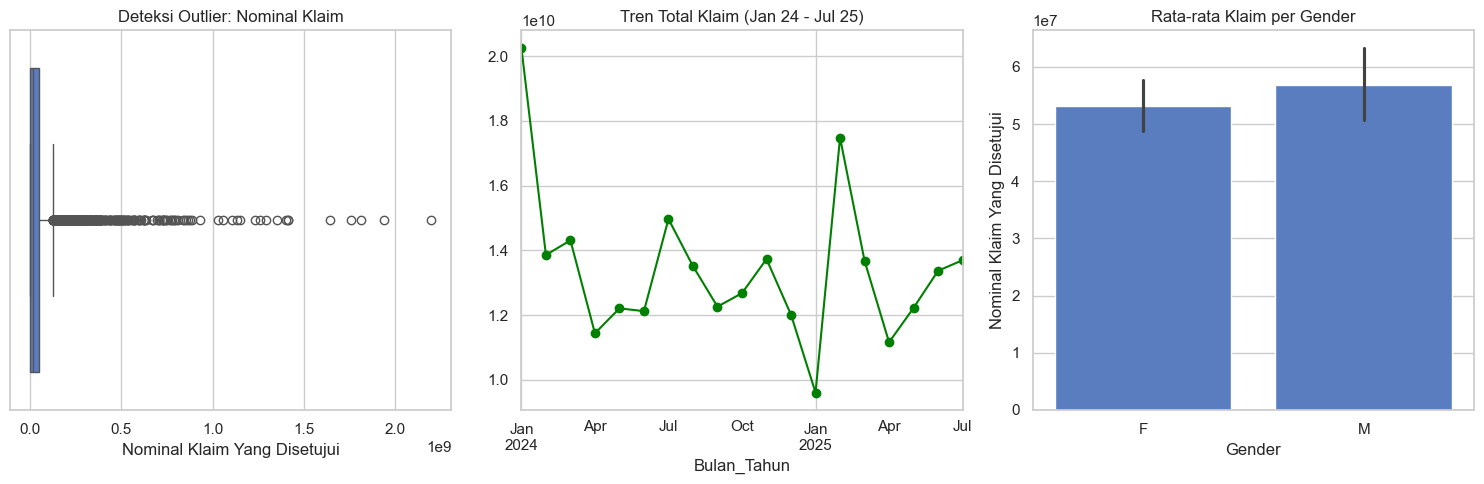

In [128]:
#Identifikasi Outlier & Visualisasi Tren
#Fokus: Melihat distribusi data "uang" dan memvalidasi tren kenaikan.

plt.figure(figsize=(15, 5))

# A. Deteksi Outlier pada Nominal Klaim (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(x=df_final['Nominal Klaim Yang Disetujui'])
plt.title('Deteksi Outlier: Nominal Klaim')

# B. Tren Total Klaim per Bulan (Line Plot)
# Validasi kenaikan 25.5%
df_final['Bulan_Tahun'] = df_final['Tanggal Pasien Masuk RS'].dt.to_period('M')
trend_data = df_final.groupby('Bulan_Tahun')['Nominal Klaim Yang Disetujui'].sum()

plt.subplot(1, 3, 2)
trend_data.plot(kind='line', marker='o', color='green')
plt.title('Tren Total Klaim (Jan 24 - Jul 25)')
plt.grid(True)

# C. Hubungan Gender vs Rata-rata Klaim (Bar Plot)
plt.subplot(1, 3, 3)
sns.barplot(data=df_final, x='Gender', y='Nominal Klaim Yang Disetujui', estimator=np.mean)
plt.title('Rata-rata Klaim per Gender')

plt.tight_layout()
plt.show()

1. Outlier Nominal Klaim:  

banyak outliers = klaim jumbo. Jangan dihapus, tapi di-log transform tuk Menormalkan Distribusi dan Meredam Skala Ekstrem. tidak dihapus karena:

    - Data Valid, Bukan Error: Dalam asuransi, klaim jumbo (titik hitam di boxplot) adalah kejadian nyata, bukan kesalahan input.

    - Risiko Sebenarnya: Menghapusnya akan membuat analisis bias. ini akan meremehkan risiko finansial perusahaan karena "membutakan" model terhadap potensi kerugian besar yang sewaktu-waktu bisa terjadi.

2. Tren: grafik garis menanjak di 2025 (sesuai dgn deskripsi kondisi)

3. Faktor: Pria dan Wanita tdk memiliki beban klaim yang berbeda signifikan.

3. FEATURE ENGINEERING

In [129]:
# 1. Hitung Usia (Saat masuk RS)
# Rumus: (Tgl Masuk - Tgl Lahir) / 365
df_final['Usia'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Lahir']).dt.days // 365


# 2. Hitung Durasi Rawat
# Rumus: Tgl Keluar - Tgl Masuk
df_final['Durasi_Rawat'] = (df_final['Tanggal Pasien Keluar RS'] - df_final['Tanggal Pasien Masuk RS']).dt.days


# 3. Ekstrak Waktu (Penting untuk Time Series Forecasting)
df_final['Bulan'] = df_final['Tanggal Pasien Masuk RS'].dt.month
df_final['Tahun'] = df_final['Tanggal Pasien Masuk RS'].dt.year
df_final['Kuartal'] = df_final['Tanggal Pasien Masuk RS'].dt.quarter


# 4. Feature Binning (Opsional): Kelompokkan Usia
# 0-18: Anak, 19-60: Dewasa, >60: Lansia
df_final['Kategori_Usia'] = pd.cut(df_final['Usia'], bins=[0, 18, 60, 100], labels=['Anak', 'Dewasa', 'Lansia'])


# 5. Hitung Masa Tunggu Polis (Dalam Hari)
# Rumus: Tgl Masuk RS - Tgl Efektif Polis
df_final['Masa_Tunggu_Hari'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Efektif Polis']).dt.days

# Bikin Binning Masa Tunggu 
# < 30 hari tunggu penyakit biasa, < 365 hari masa tunggu penyakit khusus
df_final['Kategori_Masa_Tunggu'] = pd.cut(df_final['Masa_Tunggu_Hari'], 
                                          bins=[-float('inf'), 30, 365, float('inf')], 
                                          labels=['Sangat Baru (<30 Hari)', 'Baru (<1 Tahun)', 'Lama (>1 Tahun)'])


# # 6. Grouping ICD Diagnosis (Ambil 3 karakter pertama)
# Misal: 'H26.9' menjadi 'H26'
df_final['ICD_Group'] = df_final['ICD Diagnosis'].astype(str).str[:3]


# 7. Hitung Rasio Persetujuan Klaim
# !!! Fitur ini SANGAT BAGUS buat EDA dan cari faktor berpengaruh !!!
# !!!  TAPI jangan dipake buat memprediksi Nominal Klaim masa depan (Data Leakage!) !!!
df_final['Rasio_Persetujuan'] = df_final['Nominal Klaim Yang Disetujui'] / df_final['Nominal Biaya RS Yang Terjadi']

# Handle NaN jika ada pembagian dengan 0
df_final['Rasio_Persetujuan'] = df_final['Rasio_Persetujuan'].fillna(0)


# 8. Hari dalam seminggu (0 = Senin, 6 = Minggu)
df_final['Hari_Masuk_RS'] = df_final['Tanggal Pasien Masuk RS'].dt.dayofweek

# Flagging apakah masuk RS pas Weekend (Sabtu/Minggu)?
df_final['Is_Weekend'] = df_final['Hari_Masuk_RS'].apply(lambda x: 1 if x >= 5 else 0)


# 9. Interaksi Plan Code dan Gender / Usia
df_final['Plan_Gender'] = df_final['Plan Code'].astype(str) + "_" + df_final['Gender'].astype(str)
df_final['Plan_Usia'] = df_final['Plan Code'].astype(str) + "_" + df_final['Kategori_Usia'].astype(str)

POST-FE EDA

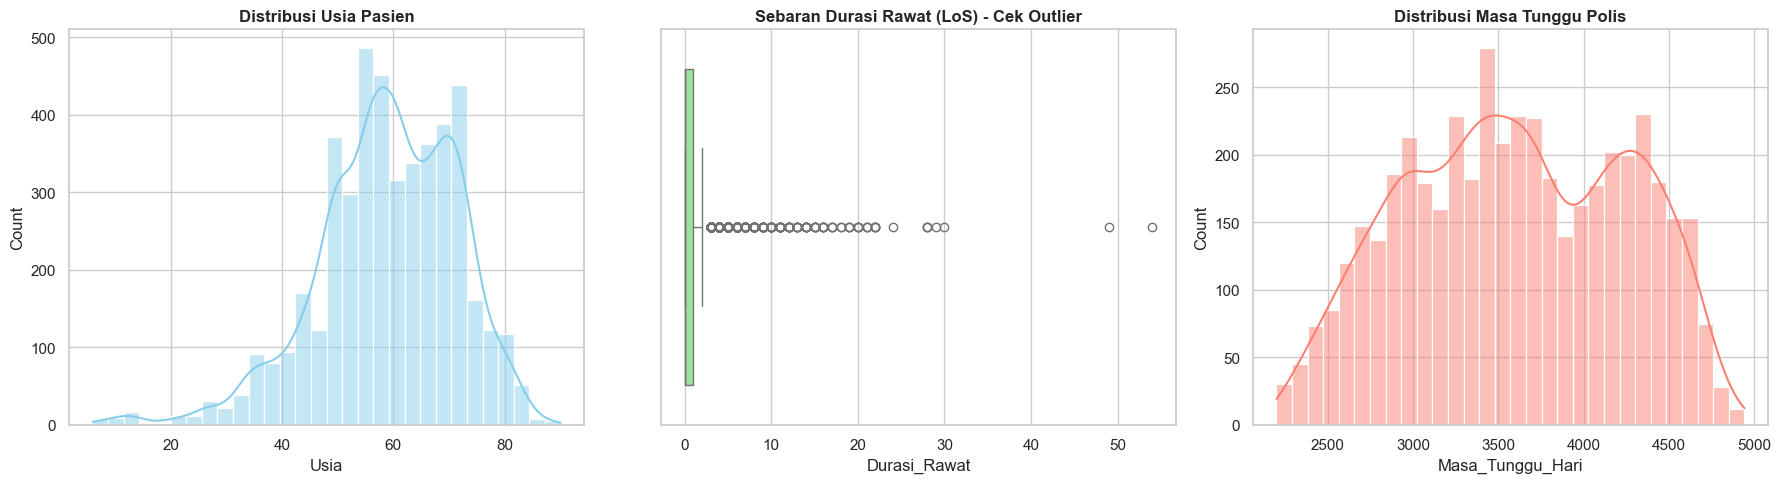

In [130]:


# Set style 
sns.set_theme(style="whitegrid", palette="muted")

# 1. Plot Distribusi Numerik (Usia, Durasi Rawat, Masa Tunggu)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_final['Usia'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Usia Pasien', fontweight='bold')

sns.boxplot(x=df_final['Durasi_Rawat'], ax=axes[1], color='lightgreen')
axes[1].set_title('Sebaran Durasi Rawat (LoS) - Cek Outlier', fontweight='bold')

sns.histplot(df_final['Masa_Tunggu_Hari'], bins=30, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribusi Masa Tunggu Polis', fontweight='bold')

plt.tight_layout()
plt.show()

- Usia: Mayoritas pasien yang mengajukan klaim berpusat di usia matang menuju senja, yaitu sekitar 50 hingga 70 tahun.

- Durasi Rawat (LoS): Secara umum pasien hanya dirawat singkat (sekitar 0-5 hari). Tapi, garis outlier (titik-titik di luar kotak hijau) menunjukkan ada pasien yang dirawat sampai lebih dari 50 hari! Pasien-pasien outlier inilah yang bikin AXA boncos.

- Masa Tunggu: Mayoritas klaim diajukan pada masa tunggu sekitar 3000 - 4500 hari (sekitar 8-12 tahun sejak polis aktif). Insight Bisnis: Ini menandakan klaim mayoritas datang dari nasabah setia/polis lama, bukan nasabah baru yang punya niat fraud atau menyembunyikan penyakit bawaan.

C:\Users\DM\AppData\Local\Temp\ipykernel_7680\856577123.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_icd_severity.values, y=top_icd_severity.index, ax=axes[0], palette='Reds_r')
C:\Users\DM\AppData\Local\Temp\ipykernel_7680\856577123.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='Kategori_Usia', y='Nominal Klaim Yang Disetujui', ax=axes[1], errorbar=None, palette='viridis')


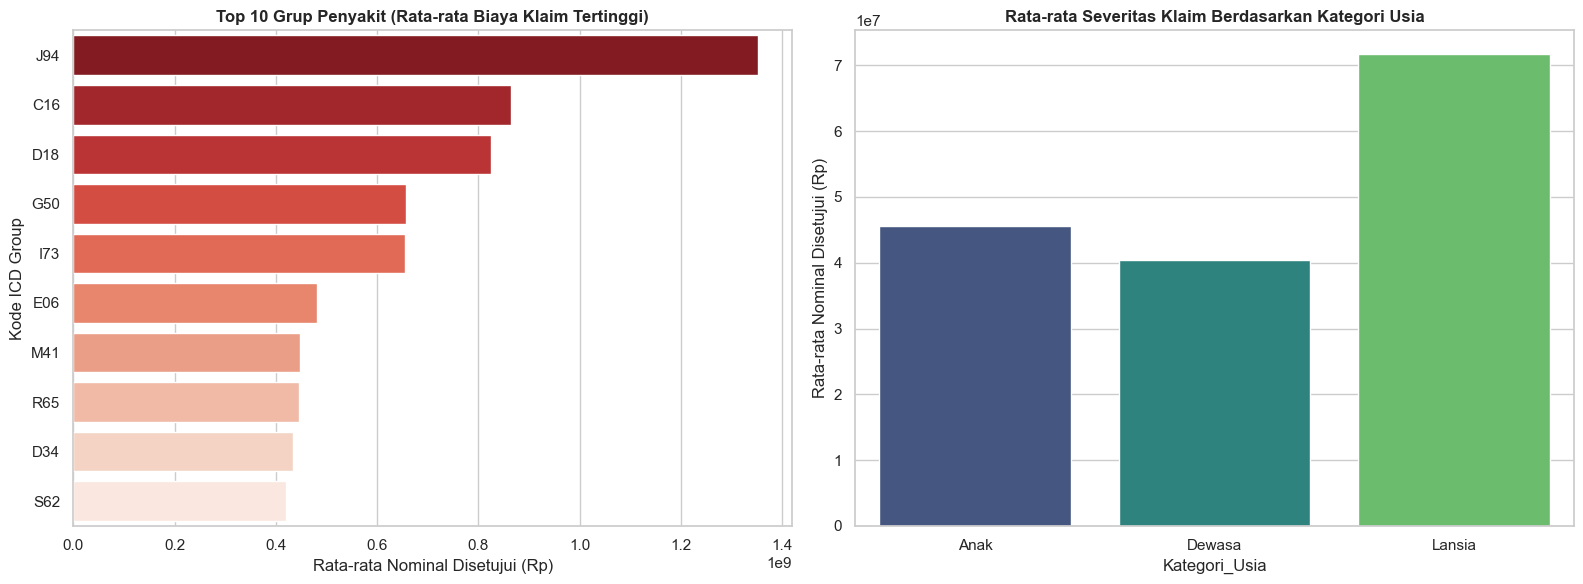

In [131]:
# 2. Analisis Fitur Kategorik vs Severitas Klaim
# Top 10 Grup Penyakit (ICD_Group) dengan Rata-rata Nominal Klaim Tertinggi
# hitung rata-ratanya (Severity)
top_icd_severity = df_final.groupby('ICD_Group')['Nominal Klaim Yang Disetujui'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot Top 10 ICD
sns.barplot(x=top_icd_severity.values, y=top_icd_severity.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 10 Grup Penyakit (Rata-rata Biaya Klaim Tertinggi)', fontweight='bold')
axes[0].set_xlabel('Rata-rata Nominal Disetujui (Rp)')
axes[0].set_ylabel('Kode ICD Group')

# Barplot Kategori Usia vs Rata-rata Klaim
sns.barplot(data=df_final, x='Kategori_Usia', y='Nominal Klaim Yang Disetujui', ax=axes[1], errorbar=None, palette='viridis')
axes[1].set_title('Rata-rata Severitas Klaim Berdasarkan Kategori Usia', fontweight='bold')
axes[1].set_ylabel('Rata-rata Nominal Disetujui (Rp)')

plt.tight_layout()
plt.show()

- Top Penyakit (ICD): Kode penyakit J94 (gangguan pleura/paru-paru) yang memakan biaya rata-rata paling ekstrem, tembus lebih dari Rp 1,2 Miliar per klaim! Disusul oleh C16 (kanker lambung) di urutan kedua.

- Usia vs Severitas: kategori Lansia memakan biaya rata-rata yang jauh melompat tinggi (di atas Rp 70 Juta) dibandingkan kategori Anak dan Dewasa yang biayanya relatif berimbang.

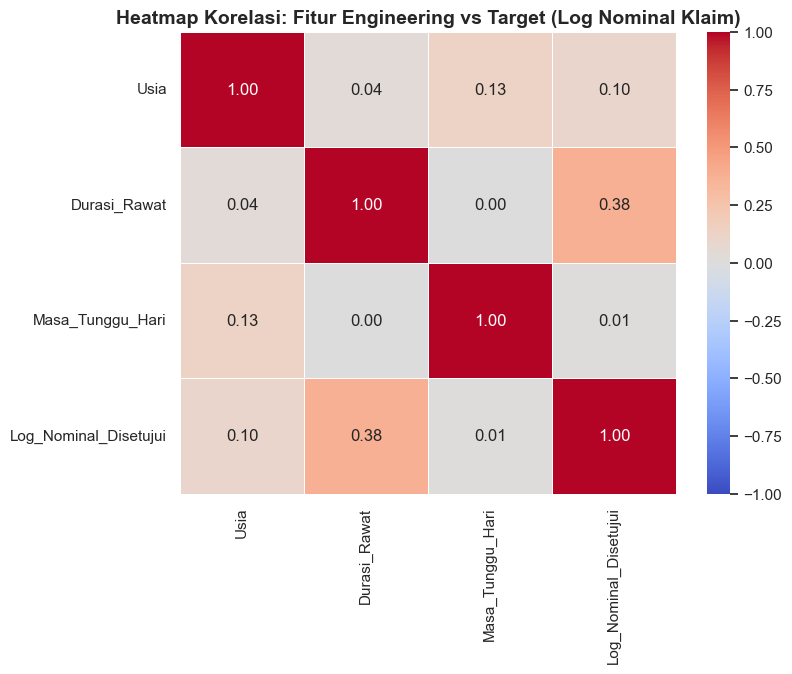

In [132]:
# 3. Apakah Durasi_Rawat berkorelasi positif kuat dengan Nominal Klaim?

# Bikin kolom log_target sementara khusus buat heatmap biar lebih akurat (karena skewed)
df_final['Log_Nominal_Disetujui'] = np.log1p(df_final['Nominal Klaim Yang Disetujui'])

# Pilih cuma kolom yang numerik biar gak error
kolom_numerik = ['Usia', 'Durasi_Rawat', 'Masa_Tunggu_Hari', 'Log_Nominal_Disetujui']
corr_matrix = df_final[kolom_numerik].corr()

# Plot Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi: Fitur Engineering vs Target (Log Nominal Klaim)', fontweight='bold', fontsize=14)
plt.show()

# Drop kolom sementara biar gak menuhin memori
df_final.drop(columns=['Log_Nominal_Disetujui'], inplace=True)

- Aktor Utama: Durasi_Rawat punya korelasi positif paling kuat (0.38) terhadap nominal klaim. Artinya, secara linear, semakin lama pasien menginap di RS, biaya klaim dipastikan makin meroket.

- Aktor Lemah: Variabel Usia (0.10) dan Masa_Tunggu (0.01) secara linear ternyata kurang berpengaruh langsung terhadap naik-turunnya nominal klaim per kejadian (meskipun usia berpengaruh kalau dikelompokkan ke kategori Lansia tadi)- .

Rekomendasi berdasarkan POST-FE VISUALIZATION:

- melakukan pengawasan ketat terhadap efisiensi lama rawat inap (Durasi Rawat) dan memperketat limit cover asuransi untuk penyakit pernapasan berat (J94).

4. PREPROCESSING - ENCODING 

In [133]:
# 1. Copy Data: df_ts -> (Level Bulanan), df_final -> (level individu)
df_ts = df_final.copy()

# diurutkan berdasarkan waktu
df_ts = df_ts.sort_values(by=['Tahun', 'Bulan'])

# 2. Agregasi (Grouping per Tahun dan Bulan)
df_monthly = df_ts.groupby(['Tahun', 'Bulan']).agg(
    Frekuensi=('Claim ID', 'count'), # Hitung jumlah klaim (Frekuensi)
    Severitas=('Nominal Klaim Yang Disetujui', 'mean'), # Rata-rata klaim (Severitas)
    Total_Klaim=('Nominal Klaim Yang Disetujui', 'sum') # Total nominal (Nominal)
).reset_index()

# Bikin kolom 'Periode' buat sumbu X kalau mau di-plot
df_monthly['Periode'] = pd.to_datetime(df_monthly['Tahun'].astype(str) + '-' + df_monthly['Bulan'].astype(str) + '-01')
df_monthly = df_monthly.sort_values('Periode').reset_index(drop=True)

# 3. Bikin Lag Features untuk masing-masing target
# Geser data 1 bulan (Lag 1) dan 2 bulan (Lag 2) ke belakang
for target in ['Frekuensi', 'Severitas', 'Total_Klaim']:
    df_monthly[f'{target}_Lag1'] = df_monthly[target].shift(1)
    df_monthly[f'{target}_Lag2'] = df_monthly[target].shift(2)
    
    # Bikin Rolling Mean (Rata-rata 3 bulan terakhir buat nangkep tren pergerakan mulus)
    df_monthly[f'{target}_RollingMean3'] = df_monthly[target].shift(1).rolling(window=3).mean()

# Drop baris yang punya nilai NaN akibat pergeseran (shift) tadi
# (Biasanya 3 bulan pertama di 2024 bakal ke-drop)
df_monthly = df_monthly.dropna().reset_index(drop=True)

In [134]:
#feature selection
# Contoh buat target 'Total_Klaim'
features = ['Bulan', 'Tahun', 'Frekuensi_Lag1', 'Severitas_Lag1', 'Total_Klaim_Lag1', 'Total_Klaim_RollingMean3']
target = 'Total_Klaim'

# Split berdasarkan waktu (Misal: ambil 3 bulan terakhir buat validasi)
train_size = len(df_monthly) - 3
train_data = df_monthly.iloc[:train_size]
val_data = df_monthly.iloc[train_size:]

X_train, y_train = train_data[features], train_data[target]
X_val, y_val = val_data[features], val_data[target]

 5. MODEL TRAINING

In [135]:
import lightgbm as lgb
import xgboost as xgb

# 1. Bikin Fungsi Evaluasi Sesuai Kriteria Kompetisi Panitia
def calculate_mape(y_true, y_pred):
    # Hindari pembagian dengan nol (berjaga-jaga)
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 2. Inisialisasi Model (Pake settingan basic dulu biar cepet)
model_lgb = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
model_xgb = xgb.XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.05, objective='reg:squarederror')

print("⏳ Sedang melatih model LightGBM dan XGBoost...")

# 3. Latih Model (Training)
model_lgb.fit(X_train, y_train)
model_xgb.fit(X_train, y_train)

# 4. Tebak Data Validasi (Predict)
pred_lgb = model_lgb.predict(X_val)
pred_xgb = model_xgb.predict(X_val)



⏳ Sedang melatih model LightGBM dan XGBoost...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 13, number of used features: 0
[LightGBM] [Info] Start training from score 12837523613.538462
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped tra

7. EVALUASI


🏆 Hasil Evaluasi Performa Model (Target: Total Klaim):


,Model Machine Learning,MAPE (Error %)
0,LightGBM,5.10%
1,XGBoost,6.96%


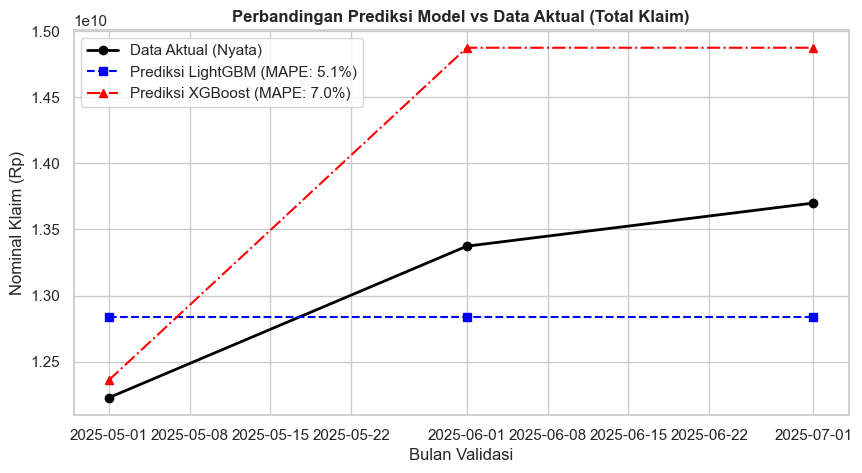

In [136]:
# 5. Hitung Skor MAPE 
mape_lgb = calculate_mape(y_val, pred_lgb)
mape_xgb = calculate_mape(y_val, pred_xgb)

# 6. Tampilkan Hasil ke Tabel (Buat screenshot di Laporan)
hasil_evaluasi = pd.DataFrame({
    'Model Machine Learning': ['LightGBM', 'XGBoost'],
    'MAPE (Error %)': [f"{mape_lgb:.2f}%", f"{mape_xgb:.2f}%"]
})

print("\n🏆 Hasil Evaluasi Performa Model (Target: Total Klaim):")
display(hasil_evaluasi)

# 7. Visualisasi Hasil Prediksi vs Aktual biar Juri Makin Yakin
plt.figure(figsize=(10, 5))
plt.plot(val_data['Periode'], y_val, marker='o', label='Data Aktual (Nyata)', color='black', linewidth=2)
plt.plot(val_data['Periode'], pred_lgb, marker='s', linestyle='--', label=f'Prediksi LightGBM (MAPE: {mape_lgb:.1f}%)', color='blue')
plt.plot(val_data['Periode'], pred_xgb, marker='^', linestyle='-.', label=f'Prediksi XGBoost (MAPE: {mape_xgb:.1f}%)', color='red')

plt.title('Perbandingan Prediksi Model vs Data Aktual (Total Klaim)', fontweight='bold')
plt.xlabel('Bulan Validasi')
plt.ylabel('Nominal Klaim (Rp)')
plt.legend()
plt.grid(True)
plt.show()

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 12, number of used features: 0
[LightGBM] [Info] Start training from score -23067822.666667
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet 

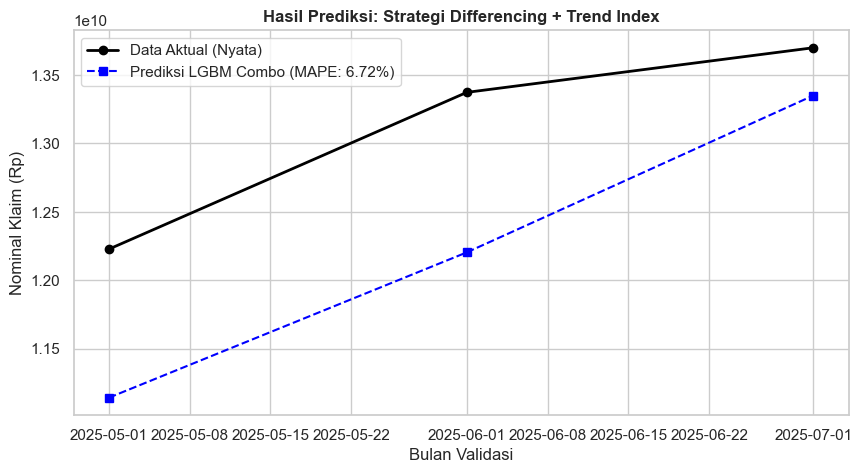

In [137]:
#Strategi Differencing ditambah Trend Index.
#memperkuat algoritma dlm ekstrapolasi

# Asumsi df_monthly lo masih utuh (belum di-drop NaN-nya)
# 1. Bikin Fitur Trend Index (Angka urut waktu dari bulan pertama sampai akhir)
df_monthly['Trend_Index'] = range(1, len(df_monthly) + 1)

# 2. Bikin Target Selisih (Differencing)
df_monthly['Total_Klaim_Diff'] = df_monthly['Total_Klaim'].diff()

# Drop NaN akibat fungsi diff() dan shift() (biasanya baris pertama)
df_monthly_kombinasi = df_monthly.dropna().reset_index(drop=True)

# 3. Setup Fitur Baru (Tambahin 'Trend_Index' ke dalam pasukan amunisi X)
features = ['Bulan', 'Tahun', 'Frekuensi_Lag1', 'Severitas_Lag1', 'Total_Klaim_Lag1', 'Trend_Index']
target_diff = 'Total_Klaim_Diff'

# 4. Split Data (Potong 3 bulan terakhir buat validasi seperti biasa)
train_size = len(df_monthly_kombinasi) - 3
train_data = df_monthly_kombinasi.iloc[:train_size]
val_data = df_monthly_kombinasi.iloc[train_size:]

X_train, y_train_diff = train_data[features], train_data[target_diff]
X_val, y_val_diff = val_data[features], val_data[target_diff]

# 5. Latih Model LightGBM dengan amunisi gabungan
model_lgb_combo = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
model_lgb_combo.fit(X_train, y_train_diff)

# 6. Prediksi Selisih (Diff)
pred_diff_combo = model_lgb_combo.predict(X_val)

# 7. REKONSTRUKSI: Kembalikan tebakan selisih ke angka asli!
# Rumus Asli = Nilai Aktual Bulan Lalu (Lag1) + Prediksi Selisih Bulan Ini
pred_asli_combo = val_data['Total_Klaim_Lag1'].values + pred_diff_combo

# 8. Hitung Ulang MAPE-nya (Semoga turun!)
y_val_asli = val_data['Total_Klaim'].values
mape_combo = np.mean(np.abs((y_val_asli - pred_asli_combo) / y_val_asli)) * 100

print(f"🔥 MAPE LightGBM (Differencing + Trend Index): {mape_combo:.2f}%")

# 9. Buktikan pakai visualisasi
plt.figure(figsize=(10, 5))
plt.plot(val_data['Periode'], y_val_asli, marker='o', label='Data Aktual (Nyata)', color='black', linewidth=2)
plt.plot(val_data['Periode'], pred_asli_combo, marker='s', linestyle='--', label=f'Prediksi LGBM Combo (MAPE: {mape_combo:.2f}%)', color='blue')

plt.title('Hasil Prediksi: Strategi Differencing + Trend Index', fontweight='bold')
plt.xlabel('Bulan Validasi')
plt.ylabel('Nominal Klaim (Rp)')
plt.legend()
plt.grid(True)
plt.show()

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 12, number of used features: 0
[LightGBM] [Info] Start training from score -16.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the sp

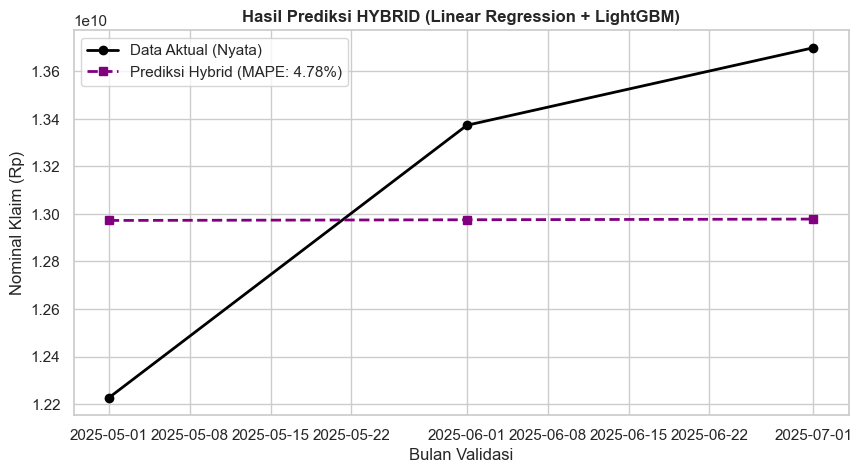

In [138]:
from sklearn.linear_model import LinearRegression

# Asumsi: df_monthly lo masih ada kolom 'Total_Klaim' dan 'Trend_Index'
features_lgb = ['Bulan', 'Tahun', 'Frekuensi_Lag1', 'Severitas_Lag1', 'Total_Klaim_Lag1']
target = 'Total_Klaim' # Kita KEMBALI pake target asli, bukan Diff

# 1. Split Data seperti biasa
train_size = len(df_monthly) - 3
train_data = df_monthly.iloc[:train_size].dropna()
val_data = df_monthly.iloc[train_size:]

X_train_lgb, y_train_asli = train_data[features_lgb], train_data[target]
X_val_lgb, y_val_asli = val_data[features_lgb], val_data[target]

X_train_trend = train_data[['Trend_Index']]
X_val_trend = val_data[['Trend_Index']]

# --- STEP 1: Biarkan Linear Regression Menebak Tren Kasar ---
lr = LinearRegression()
lr.fit(X_train_trend, y_train_asli)

trend_train = lr.predict(X_train_trend)
trend_val = lr.predict(X_val_trend)

# --- STEP 2: Hitung Residual (Error) dari Linear Regression ---
# Kita cari selisih antara nilai asli vs tebakan tren
y_train_residual = y_train_asli - trend_train

# --- STEP 3: Biarkan LightGBM Menebak Pola Residuals ---
model_lgb_resid = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
model_lgb_resid.fit(X_train_lgb, y_train_residual)

pred_resid_val = model_lgb_resid.predict(X_val_lgb)

# --- STEP 4: GABUNGKAN (Hybrid Prediksi Akhir) ---
# Prediksi Akhir = Tebakan Tren + Tebakan Residual
final_pred = trend_val + pred_resid_val

# Evaluasi
mape_hybrid = np.mean(np.abs((y_val_asli - final_pred) / y_val_asli)) * 100
print(f"🔥 MAPE Model Hybrid (LinReg + LightGBM): {mape_hybrid:.2f}%")

# Visualisasi Pembuktian
plt.figure(figsize=(10, 5))
plt.plot(val_data['Periode'], y_val_asli, marker='o', label='Data Aktual (Nyata)', color='black', linewidth=2)
plt.plot(val_data['Periode'], final_pred, marker='s', linestyle='--', label=f'Prediksi Hybrid (MAPE: {mape_hybrid:.2f}%)', color='purple', linewidth=2)

plt.title('Hasil Prediksi HYBRID (Linear Regression + LightGBM)', fontweight='bold')
plt.xlabel('Bulan Validasi')
plt.ylabel('Nominal Klaim (Rp)')
plt.legend()
plt.grid(True)
plt.show()

8. POST-MODELLING (ANALISA)

9. PREDICTION & RECOMENDATIONS

In [139]:
#submisi pake baseline 

print("🔥 Menggabungkan Model LightGBM & Format Kaggle yang Bener...")

# 1. SETUP TARGET & TRAINING ULANG (Pakai Semua Data)
targets_mapping = {
    'Frekuensi': 'Claim_Frequency',
    'Severitas': 'Claim_Severity',
    'Total_Klaim': 'Total_Claim'
}

fitur_lgb = ['Bulan', 'Tahun', 'Frekuensi_Lag1', 'Severitas_Lag1', 'Total_Klaim_Lag1']
models_lgb = {}

for target_indo in targets_mapping.keys():
    lgbm = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
    lgbm.fit(df_monthly[fitur_lgb], df_monthly[target_indo])
    models_lgb[target_indo] = lgbm

# 2. ITERATIVE FORECASTING & BIKIN KAMUS PREDIKSI
baris_terakhir = df_monthly.iloc[-1]
last_freq = baris_terakhir['Frekuensi']
last_sev = baris_terakhir['Severitas']
last_tot = baris_terakhir['Total_Klaim']

kamus_prediksi = {}

for bulan in [8, 9, 10, 11, 12]:
    X_future = pd.DataFrame({
        'Bulan': [bulan],
        'Tahun': [2025],
        'Frekuensi_Lag1': [last_freq],
        'Severitas_Lag1': [last_sev],
        'Total_Klaim_Lag1': [last_tot]
    })
    
    preds_bulan_ini = {}
    
    for target_indo, target_kaggle in targets_mapping.items():
        p_final = max(0, models_lgb[target_indo].predict(X_future)[0])
        preds_bulan_ini[target_indo] = p_final
        
        # --- INI DIA KUNCI JAWABANNYA! PAKAI UNDERSCORE (_) ---
        id_string = f"2025_{bulan:02d}_{target_kaggle}"
        kamus_prediksi[id_string] = p_final
        
    # Update Lag buat bulan depan
    last_freq = preds_bulan_ini['Frekuensi']
    last_sev = preds_bulan_ini['Severitas']
    last_tot = preds_bulan_ini['Total_Klaim']

# 3. OVERWRITE FILE PANITIA
print("\n📂 Menimpa file 'sample_submission.csv'...")
df_sub = pd.read_csv('sample_submission.csv')

# Cocokkan berdasarkan kamus yang formatnya udah bener
df_sub['value'] = df_sub['id'].map(kamus_prediksi)

# Cek akhir
jumlah_nol = df_sub['value'].isna().sum()
if jumlah_nol > 0:
    print(f"⚠️ Masih ada {jumlah_nol} baris yang kosong/NaN!")
else:
    print("✅ BERHASIL! Semua angka udah masuk dengan sempurna!")

display(df_sub.head())

# Save ke CSV
df_sub.to_csv('submission_AXA_FinalBanget.csv', index=False)
print("\n🎉 File 'submission_AXA_FinalBanget.csv' siap disubmit!")

🔥 Menggabungkan Model LightGBM & Format Kaggle yang Bener...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 0
[LightGBM] [Info] Start training from score 239.937500
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopp

,id,value
0,2025_08_Claim_Frequency,2.399375e+02
1,2025_08_Claim_Severity,5.382472e+07
2,2025_08_Total_Claim,1.288668e+10
3,2025_09_Claim_Frequency,2.399375e+02
4,2025_09_Claim_Severity,5.382472e+07



🎉 File 'submission_AXA_FinalBanget.csv' siap disubmit!


In [141]:
#submiisi pake lightgbm + differencing


print("📈 Menghitung Selisih (Differencing) & Training Model...")

# 1. BIKIN TARGET SELISIH (Diff)
# Kita hitung selisih bulan ini dikurang bulan lalu
df_diff = df_monthly.copy()
targets_indo = ['Frekuensi', 'Severitas', 'Total_Klaim']

for t in targets_indo:
    df_diff[f'{t}_Diff'] = df_diff[t].diff() # Selisih dengan baris sebelumnya

# 2. SETUP FITUR & DROPS NaN
# Karena baris pertama pasti NaN setelah .diff() dan .shift(), kita buang.
fitur_lgb = ['Bulan', 'Tahun', 'Frekuensi_Lag1', 'Severitas_Lag1', 'Total_Klaim_Lag1']
df_clean = df_diff.dropna(subset=[f'{t}_Diff' for t in targets_indo] + fitur_lgb)

models_diff = {}
for t in targets_indo:
    # Model belajar menebak "BERAPA KENAIKANNYA" bukan "BERAPA NILAINYA"
    lgbm = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
    lgbm.fit(df_clean[fitur_lgb], df_clean[f'{t}_Diff'])
    models_diff[t] = lgbm

# 3. PREDIKSI ITERATIF (Re-integrasi)
# Kita butuh angka asli bulan Juli sebagai pijakan awal
last_actuals = df_monthly.iloc[-1][targets_indo].to_dict()
last_lags = {
    'Frekuensi_Lag1': last_actuals['Frekuensi'],
    'Severitas_Lag1': last_actuals['Severitas'],
    'Total_Klaim_Lag1': last_actuals['Total_Klaim']
}

targets_mapping = {'Frekuensi': 'Claim_Frequency', 'Severitas': 'Claim_Severity', 'Total_Klaim': 'Total_Claim'}
kamus_prediksi = {}

for bulan in [8, 9, 10, 11, 12]:
    X_future = pd.DataFrame({
        'Bulan': [bulan],
        'Tahun': [2025],
        'Frekuensi_Lag1': [last_lags['Frekuensi_Lag1']],
        'Severitas_Lag1': [last_lags['Severitas_Lag1']],
        'Total_Klaim_Lag1': [last_lags['Total_Klaim_Lag1']]
    })
    
    current_preds = {}
    for t_indo, t_kaggle in targets_mapping.items():
        # Tebak selisihnya
        selisih_pred = models_diff[t_indo].predict(X_future)[0]
        
        # NILAI ASLI = Nilai Bulan Lalu + Selisih
        nilai_asli = max(0, last_actuals[t_indo] + selisih_pred)
        
        current_preds[t_indo] = nilai_asli
        kamus_prediksi[f"2025_{bulan:02d}_{t_kaggle}"] = nilai_asli
        
    # Update buat iterasi bulan berikutnya
    for t in targets_indo:
        last_actuals[t] = current_preds[t]
    
    last_lags = {
        'Frekuensi_Lag1': current_preds['Frekuensi'],
        'Severitas_Lag1': current_preds['Severitas'],
        'Total_Klaim_Lag1': current_preds['Total_Klaim']
    }

# 4. SUBMIT KE FORMAT KAGGLE
df_sub = pd.read_csv('sample_submission.csv')
df_sub['value'] = df_sub['id'].map(kamus_prediksi)

# Cek apakah ada yang NaN atau 0 aneh
print(f"Jumlah baris terisi: {df_sub['value'].notna().sum()} / {len(df_sub)}")

df_sub.to_csv('submission_LGBM_Difference.csv', index=False)
print("✅ Selesai! File 'submission_LGBM_Difference.csv' siap diadu!")
display(df_sub.head(6))

📈 Menghitung Selisih (Differencing) & Training Model...
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 15, number of used features: 0
[LightGBM] [Info] Start training from score 1.666667
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped trai

,id,value
0,2025_08_Claim_Frequency,2.656667e+02
1,2025_08_Claim_Severity,5.215904e+07
2,2025_08_Total_Claim,1.384977e+10
3,2025_09_Claim_Frequency,2.673333e+02
4,2025_09_Claim_Severity,5.242707e+07
5,2025_09_Total_Claim,1.400031e+10


In [140]:
#submisi pake hybrid 

# 1. SETUP TARGET
targets_mapping = {'Frekuensi': 'Claim_Frequency', 'Severitas': 'Claim_Severity', 'Total_Klaim': 'Total_Claim'}
models_lr, models_lgb = {}, {}

# 2. TRAINING HYBRID (Retrain All Data)
for t_indo in targets_mapping.keys():
    # Linear Trend
    lr = LinearRegression()
    lr.fit(df_monthly[['Trend_Index']], df_monthly[t_indo])
    models_lr[t_indo] = lr
    
    # Residuals for LightGBM
    residuals = df_monthly[t_indo] - lr.predict(df_monthly[['Trend_Index']])
    lgbm = lgb.LGBMRegressor(random_state=42, n_estimators=100)
    lgbm.fit(df_monthly[['Bulan', 'Tahun', 'Frekuensi_Lag1', 'Severitas_Lag1', 'Total_Klaim_Lag1']], residuals)
    models_lgb[t_indo] = lgbm

# 3. PREDIKSI (AGUSTUS - DESEMBER)
last_freq, last_sev, last_tot = df_monthly.iloc[-1][['Frekuensi', 'Severitas', 'Total_Klaim']]
last_trend = df_monthly.iloc[-1]['Trend_Index']
kamus_prediksi = {}

for bulan in [8, 9, 10, 11, 12]:
    curr_trend = last_trend + 1
    X_lgb = pd.DataFrame({'Bulan':[bulan], 'Tahun':[2025], 'Frekuensi_Lag1':[last_freq], 'Severitas_Lag1':[last_sev], 'Total_Klaim_Lag1':[last_tot]})
    
    temp_preds = {}
    for t_indo, t_kaggle in targets_mapping.items():
        val = max(0, models_lr[t_indo].predict([[curr_trend]])[0] + models_lgb[t_indo].predict(X_lgb)[0])
        temp_preds[t_indo] = val
        # FORMAT FIX: 2025_08_...
        kamus_prediksi[f"2025_{bulan:02d}_{t_kaggle}"] = val
        
    last_freq, last_sev, last_tot, last_trend = temp_preds['Frekuensi'], temp_preds['Severitas'], temp_preds['Total_Klaim'], curr_trend

# 4. OVERWRITE & SAVE
df_sub = pd.read_csv('sample_submission.csv')
df_sub['value'] = df_sub['id'].map(kamus_prediksi)
df_sub.to_csv('submission_HYBRID_FINAL.csv', index=False)
print("✅ Hybrid Model Ready! Format ID '2025_08' udah fix.")

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.


[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 16, number of used features: 0
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because t

c:\Users\DM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarn